In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("Tatacoffee13_21.csv",parse_dates=["Date"],index_col='Date')

In [5]:
dataset

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2225 entries, 2013-01-01 to 2021-12-28
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2225 non-null   float64
 1   High    2225 non-null   float64
 2   Low     2225 non-null   float64
 3   Close   2225 non-null   float64
dtypes: float64(4)
memory usage: 86.9 KB


In [9]:
#Start date and end_date
from datetime import date, timedelta
import pandas as pd
start_date = pd.to_datetime("2013-01-01")
end_date = pd.to_datetime("2019-02-04") - timedelta(days=1) #Excluding last

#List of all dates
all_date = pd.date_range(start_date, end_date, freq='d')

In [11]:
all_date

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2019-01-25', '2019-01-26', '2019-01-27', '2019-01-28',
               '2019-01-29', '2019-01-30', '2019-01-31', '2019-02-01',
               '2019-02-02', '2019-02-03'],
              dtype='datetime64[ns]', length=2225, freq='D')

In [13]:
dummyDate=dataset

In [15]:
dummyDate.index=all_date
dummyDate

,Open,High,Low,Close
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-05,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2019-01-30,202.90,207.80,201.35,205.00
2019-01-31,206.00,206.85,202.05,202.95
2019-02-01,203.90,203.90,199.35,201.00
2019-02-02,200.00,222.00,196.00,218.35


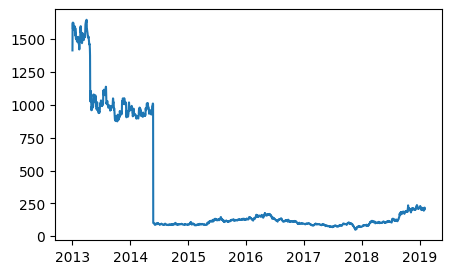

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(dataset["Close"])
plt.show()

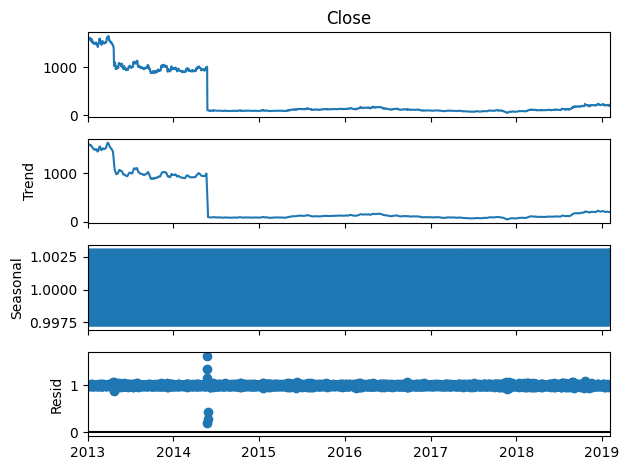

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(dummyDate["Close"],model="multiplicative")
result.plot()
plt.show()

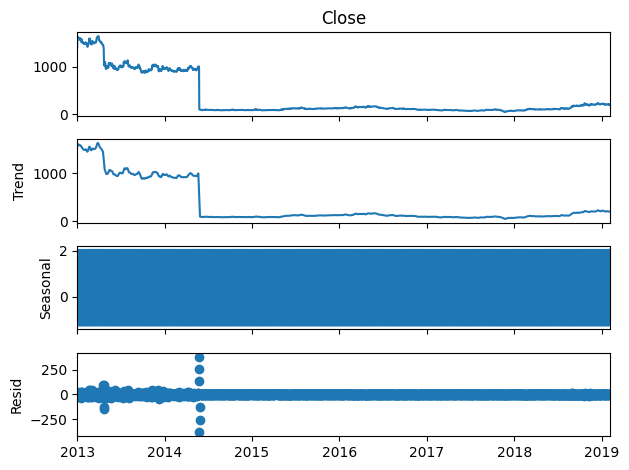

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(dummyDate["Close"],model="additive")
result.plot()
plt.show()

In [20]:
#!pip install statsmodels

Results of Dickey-Fuller Test
Test Statistic              -3.007236
p-value                      0.034224
#Lags used                   1.000000
Number of Observations    2223.000000
Critical Value (1%)         -3.433295
Critical Value (5%)         -2.862841
Critical Value (10%)        -2.567463
dtype: float64


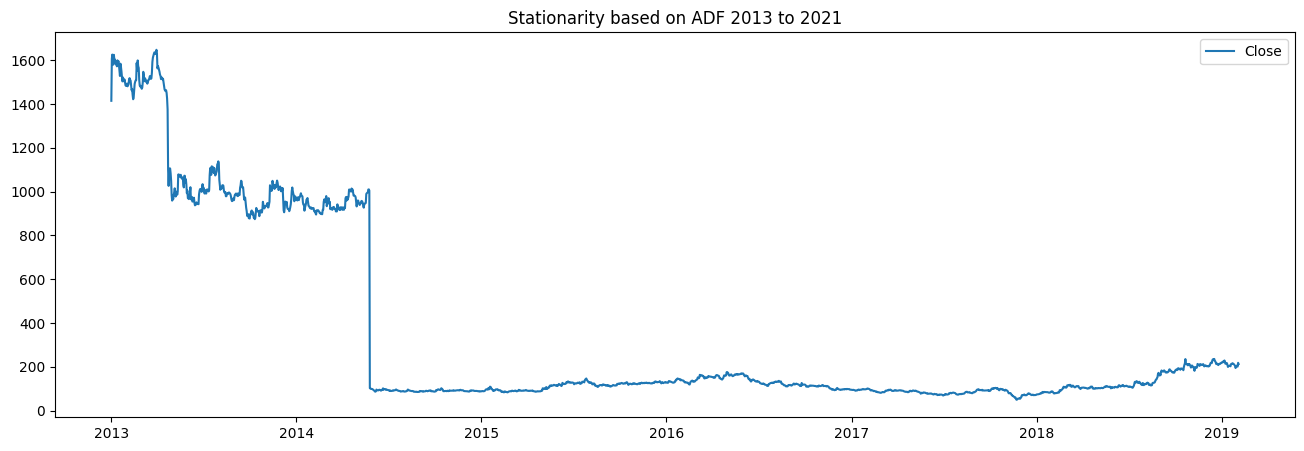

'Stationarity based on ADF'


In [22]:
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-Fuller Test")
dftest=adfuller(dataset["Close"],autolag='AIC')
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic","p-value","#Lags used","Number of Observations"])
for key,value in dftest[4].items():
    dfoutput["Critical Value (%s)" %key]=value
print(dfoutput)
ans=dfoutput
if((ans["Test Statistic"]<ans["Critical Value (1%)"] or ans["Test Statistic"]<ans["Critical Value (5%)"] or ans["Test Statistic"]< ans["Critical Value (10%)"]) and ans["p-value"]<=0.05):
    message="Stationarity based on ADF"
else:
    message="Non-Stationarity based on ADF"
plt.figure(figsize=(16,5))
plt.plot(dataset.index,dataset["Close"],label="Close")
plt.title(f"{message} 2013 to 2021")
plt.legend(loc='best')
plt.show()
print(f"'{message}'")


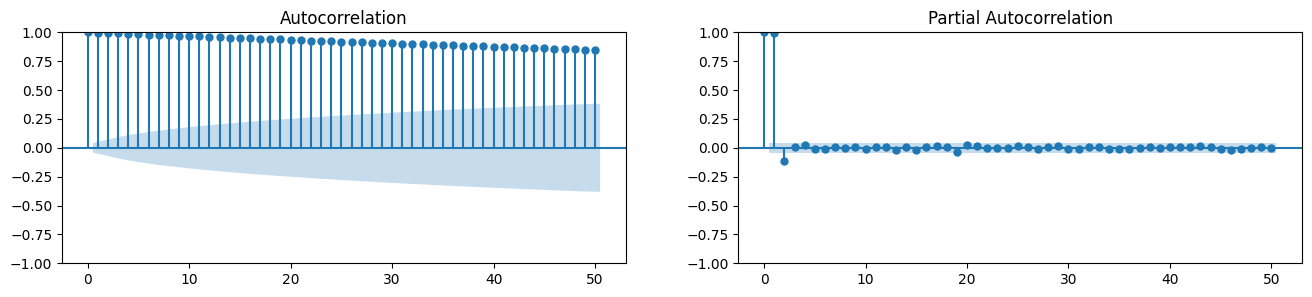

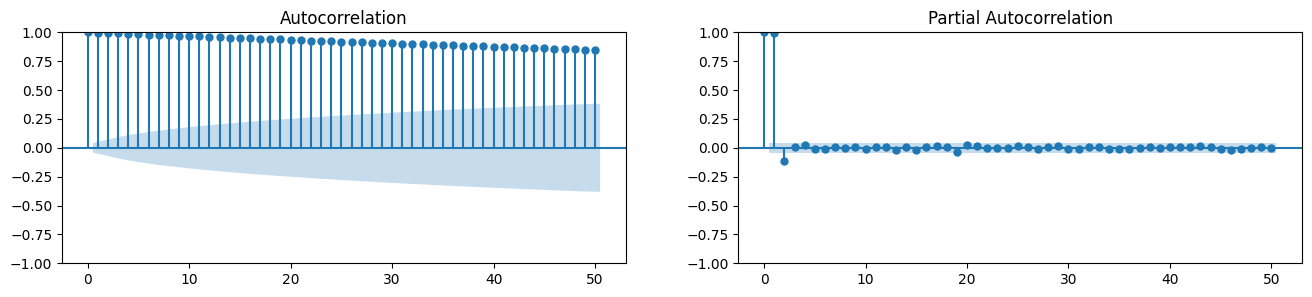

In [23]:
from statsmodels.tsa.stattools import acf,pacf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
fig,axes=plt.subplots(1,2,figsize=(16,3),dpi=100)
plot_acf(dataset["Close"],lags=50,ax=axes[0])
plot_pacf(dataset["Close"],lags=50,ax=axes[1])

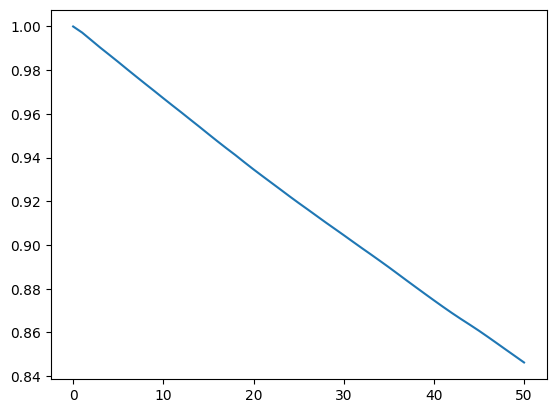

In [24]:
plt.plot(acf(dataset["Close"],nlags=50))

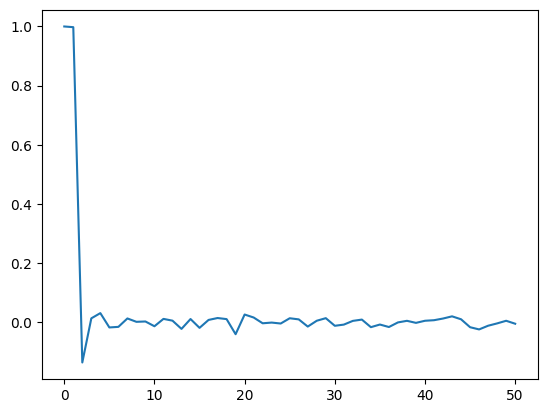

In [25]:
plt.plot(pacf(dataset["Close"],nlags=50))

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

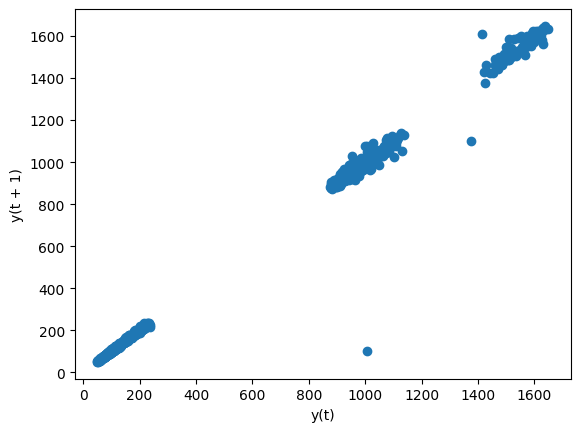

In [26]:
from pandas.plotting import lag_plot
lag_plot(dataset["Close"],lag=1)

In [27]:
def Apen(u,m,r):
    def phi(u,m,r):
        import numpy as np
        N=len(u)
        vectors=[]
        for i in range(N-m+1):
            temp=[]
            for j in range(i,i+m):
                temp.append(u[j])
            vectors.append(temp)
        c=[]
        for i in vectors:
            count=0
            total_vectors=len(vectors)
            for j in vectors:
                diff=[]
                for index in range(len(i)):
                    difference=abs(i[index]-j[index])
                    diff.append(difference)
                distances=max(diff)
                if distances<=r:
                    count+=1
            value=count/total_vectors
            c.append(value)
        lo=np.log(c)
        su=np.sum(lo)
        phi=su/total_vectors
        return phi
    phi2=phi(u,m,r)
    phi3=phi(u,m+1,r)
    Apen=abs(phi2-phi3)
    return Apen

In [28]:
Apen([1,2,1,2,1],2,0.5)

np.float64(0.0566330122651324)

In [47]:
def sampen(u,m,r):
    def count_m(u,m,r):
        N=len(u)
        vectors=[]
        for i in range(N-m+1):
            temp=[]
            for j in range(i,i+m):
                temp.append(u[j])
            vectors.append(temp)
        count=0
        for i in range(len(vectors)):
            for j in range(i+1,len(vectors)):
                    diff=[]
                    for index in range(len(vectors[i])):
                        difference=abs(vectors[i][index]-vectors[j][index])
                        diff.append(difference)
                    distance=max(diff)
                    if distance<=r:
                        count+=1
        return count
    B=count_m(u,m,r)
    A=count_m(u,m+1,r)
    if A == 0 or B == 0:
        return np.inf
    SampEn=-np.log(A/B)
    return SampEn
                    
            

In [49]:
sampen([1,2,1,2,1],2,0.5)

np.float64(0.6931471805599453)

In [51]:
def ApEn(U, m, r):
    """Compute Aproximate entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    N = len(U)
    return abs(_phi(m+1) - _phi(m))

In [53]:
ApEn([1,2,1,2,1],2,0.5)

np.float64(0.05663301226513251)

In [55]:
import numpy as np


In [57]:
def SampEn(U, m, r):
    """Compute Sample entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        return sum(C)

    N = len(U)
    return -np.log(_phi(m+1) / _phi(m))

In [59]:
SampEn([1,2,1,2,1],2,0.5)

np.float64(0.6931471805599453)